In [1]:
import pandas as pd
import os

In [3]:
os.getcwd()

'C:\\Users\\shane\\Desktop\\PPC\\Module 5'

In [5]:
movies = pd.read_csv("P4-Movie-Ratings.csv")

In [6]:
len(movies)

559

In [7]:
movies.head()

,Film,Genre,Rotten Tomatoes Ratings %,Audience Ratings %,Budget (million $),Year of release
0,(500) Days of Summer,Comedy,87,81,8,2009
1,"10,000 B.C.",Adventure,9,44,105,2008
2,12 Rounds,Action,30,52,20,2009
3,127 Hours,Adventure,93,84,18,2010
4,17 Again,Comedy,55,70,20,2009


In [8]:
movies.columns

Index(['Film', 'Genre', 'Rotten Tomatoes Ratings %', 'Audience Ratings %',
       'Budget (million $)', 'Year of release'],
      dtype='object')

In [9]:
movies.columns = ['Film',"Genre","CriticRating","AudienceRating","BudgetMillions","Year"]

In [10]:
movies.head()

,Film,Genre,CriticRating,AudienceRating,BudgetMillions,Year
0,(500) Days of Summer,Comedy,87,81,8,2009
1,"10,000 B.C.",Adventure,9,44,105,2008
2,12 Rounds,Action,30,52,20,2009
3,127 Hours,Adventure,93,84,18,2010
4,17 Again,Comedy,55,70,20,2009


In [12]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559 entries, 0 to 558
Data columns (total 6 columns):
Film              559 non-null object
Genre             559 non-null object
CriticRating      559 non-null int64
AudienceRating    559 non-null int64
BudgetMillions    559 non-null int64
Year              559 non-null int64
dtypes: int64(4), object(2)
memory usage: 26.3+ KB


In [13]:
movies.describe()

,CriticRating,AudienceRating,BudgetMillions,Year
count,559.000000,559.000000,559.000000,559.000000
mean,47.309481,58.744186,50.236136,2009.152057
std,26.413091,16.826887,48.731817,1.362632
min,0.000000,0.000000,0.000000,2007.000000
25%,25.000000,47.000000,20.000000,2008.000000
50%,46.000000,58.000000,35.000000,2009.000000
75%,70.000000,72.000000,65.000000,2010.000000
max,97.000000,96.000000,300.000000,2011.000000


In [17]:
movies.Film = movies.Film.astype('category')

In [18]:
movies.head()

,Film,Genre,CriticRating,AudienceRating,BudgetMillions,Year
0,(500) Days of Summer,Comedy,87,81,8,2009
1,"10,000 B.C.",Adventure,9,44,105,2008
2,12 Rounds,Action,30,52,20,2009
3,127 Hours,Adventure,93,84,18,2010
4,17 Again,Comedy,55,70,20,2009


In [19]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559 entries, 0 to 558
Data columns (total 6 columns):
Film              559 non-null category
Genre             559 non-null object
CriticRating      559 non-null int64
AudienceRating    559 non-null int64
BudgetMillions    559 non-null int64
Year              559 non-null int64
dtypes: category(1), int64(4), object(1)
memory usage: 47.4+ KB


In [20]:
movies.Genre = movies.Genre.astype('category')
movies.Year = movies.Year.astype('category')

In [21]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559 entries, 0 to 558
Data columns (total 6 columns):
Film              559 non-null category
Genre             559 non-null category
CriticRating      559 non-null int64
AudienceRating    559 non-null int64
BudgetMillions    559 non-null int64
Year              559 non-null category
dtypes: category(3), int64(3)
memory usage: 40.3 KB


In [22]:
movies.Genre.cat.categories

Index(['Action', 'Adventure', 'Comedy', 'Drama', 'Horror', 'Romance',
       'Thriller'],
      dtype='object')

In [23]:
movies.describe()

,CriticRating,AudienceRating,BudgetMillions
count,559.000000,559.000000,559.000000
mean,47.309481,58.744186,50.236136
std,26.413091,16.826887,48.731817
min,0.000000,0.000000,0.000000
25%,25.000000,47.000000,20.000000
50%,46.000000,58.000000,35.000000
75%,70.000000,72.000000,65.000000
max,97.000000,96.000000,300.000000


In [24]:
#JointPLots

In [29]:
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

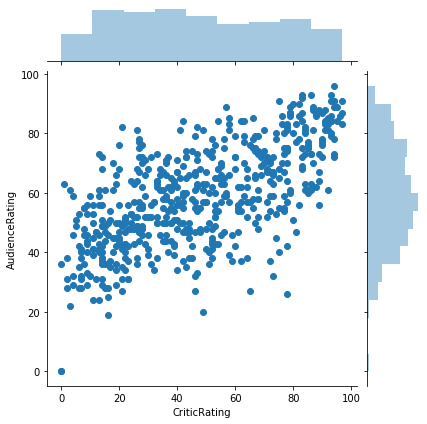

In [31]:
j = sns.jointplot(data=movies, x="CriticRating",y="AudienceRating")

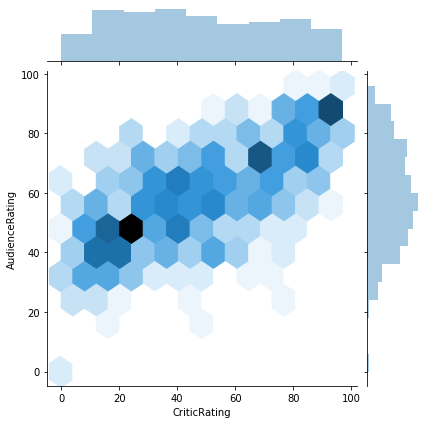

In [32]:
j = sns.jointplot(data=movies, x="CriticRating",y="AudienceRating",kind="hex")

In [33]:
# Histograms

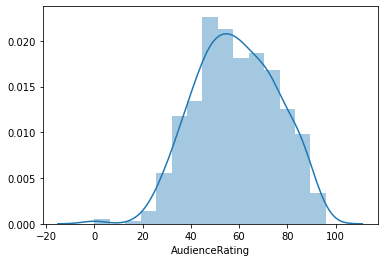

In [35]:
m1 = sns.distplot(movies.AudienceRating, bins=15)

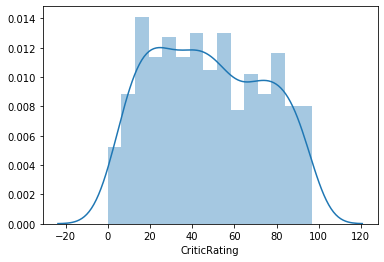

In [36]:
m1 = sns.distplot(movies.CriticRating, bins=15)

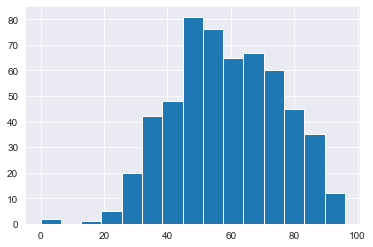

In [38]:
sns.set_style("darkgrid")
n1 = plt.hist(movies.AudienceRating, bins=15)

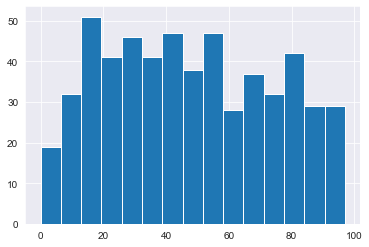

In [39]:
n1 = plt.hist(movies.CriticRating, bins=15)

In [40]:
#Stacked Histograms

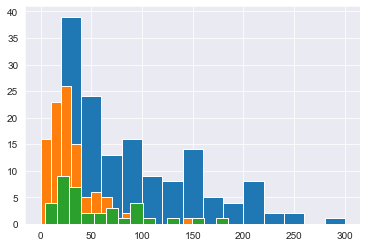

In [49]:
h1 = plt.hist(movies[movies.Genre == "Action"].BudgetMillions, bins=15)
h1 = plt.hist(movies[movies.Genre == "Drama"].BudgetMillions, bins=15)
h1 = plt.hist(movies[movies.Genre == "Thriller"].BudgetMillions, bins=15)
plt.show()

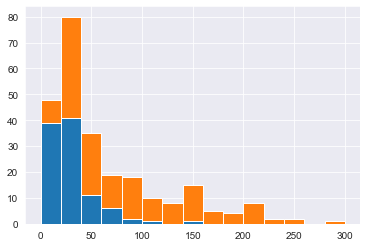

In [56]:
plt.hist([movies[movies.Genre == "Drama"].BudgetMillions , movies[movies.Genre == "Action"].BudgetMillions], bins=15, stacked=True)
plt.show()

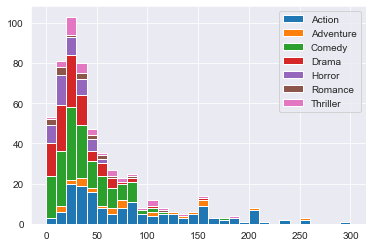

In [66]:
list1 = list()
mylables=list()
for gen in movies.Genre.cat.categories:
        list1.append(movies[movies.Genre == gen].BudgetMillions)
        mylables.append(gen)
h = plt.hist(list1, bins=30, stacked=True, rwidth=1, label=mylables)
plt.legend()
plt.show()

In [67]:
#KDE PLOT

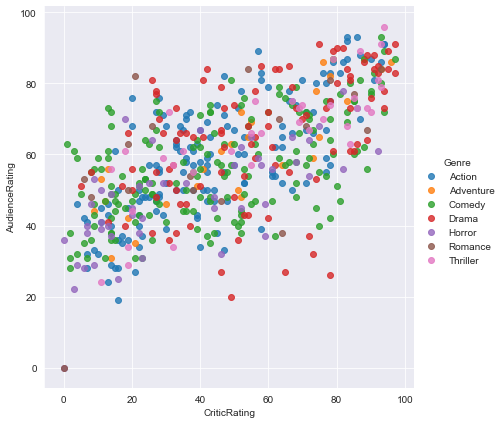

In [75]:
vis1 = sns.lmplot(data=movies, x="CriticRating", y="AudienceRating", fit_reg=False, hue="Genre", size = 6,aspect = 1)

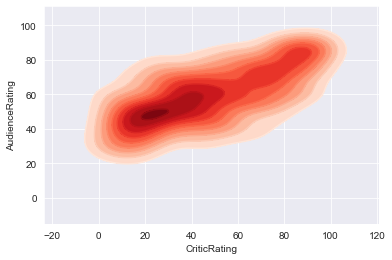

In [81]:
k1 = sns.kdeplot(movies.CriticRating, movies.AudienceRating, shade = True, shade_lowest=False, cmap="Reds")
k1 = sns.kdeplot(movies.CriticRating, movies.AudienceRating, cmap="Reds")

In [82]:
#Working with Subplots

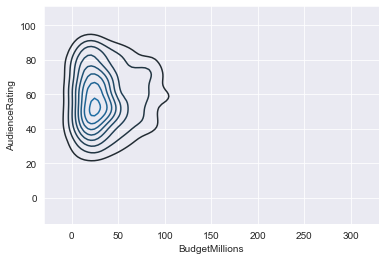

In [85]:
k1 = sns.kdeplot(movies.BudgetMillions, movies.AudienceRating)

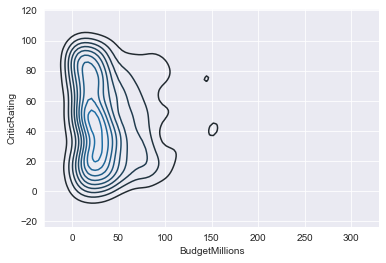

In [89]:
k2 = sns.kdeplot(movies.BudgetMillions, movies.CriticRating)

[(-20, 160)]

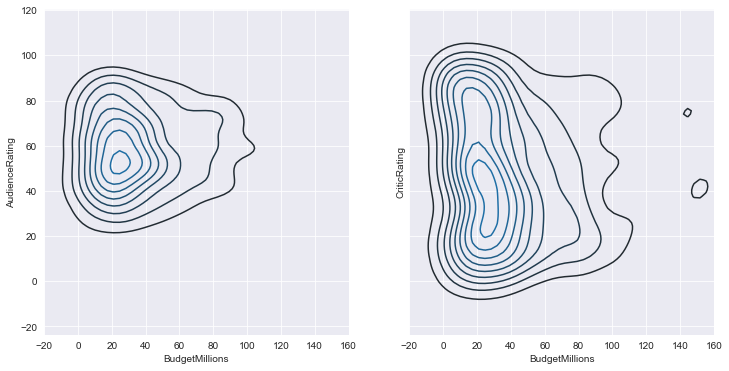

In [112]:
f , axis = plt.subplots(1,2, figsize=(12,6), sharex=True, sharey=True)
k1 = sns.kdeplot(movies.BudgetMillions, movies.AudienceRating, ax=axis[0])
k2 = sns.kdeplot(movies.BudgetMillions, movies.CriticRating, ax=axis[1])
k1.set(xlim=(-20,160))

In [97]:
axis

array([<matplotlib.axes._subplots.AxesSubplot object at 0x00000264551E8DA0>,
      dtype=object)

In [114]:
#Violin vs Boxplots

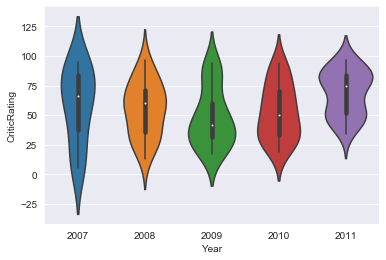

In [119]:
z = sns.violinplot(data=movies[movies.Genre=="Drama"],x="Year",y="CriticRating")

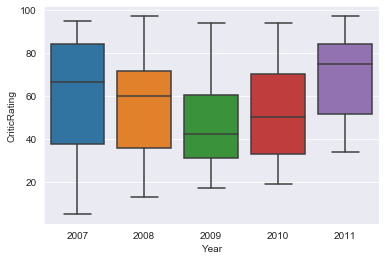

In [118]:
w = sns.boxplot(data=movies[movies.Genre=="Drama"],x="Year",y="CriticRating")

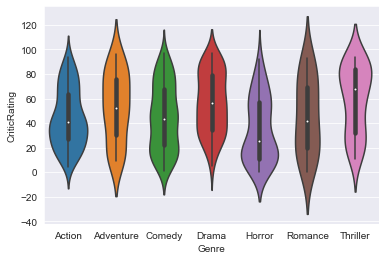

In [120]:
z = sns.violinplot(data=movies,x="Genre",y="CriticRating")

In [121]:
#Facet Grid

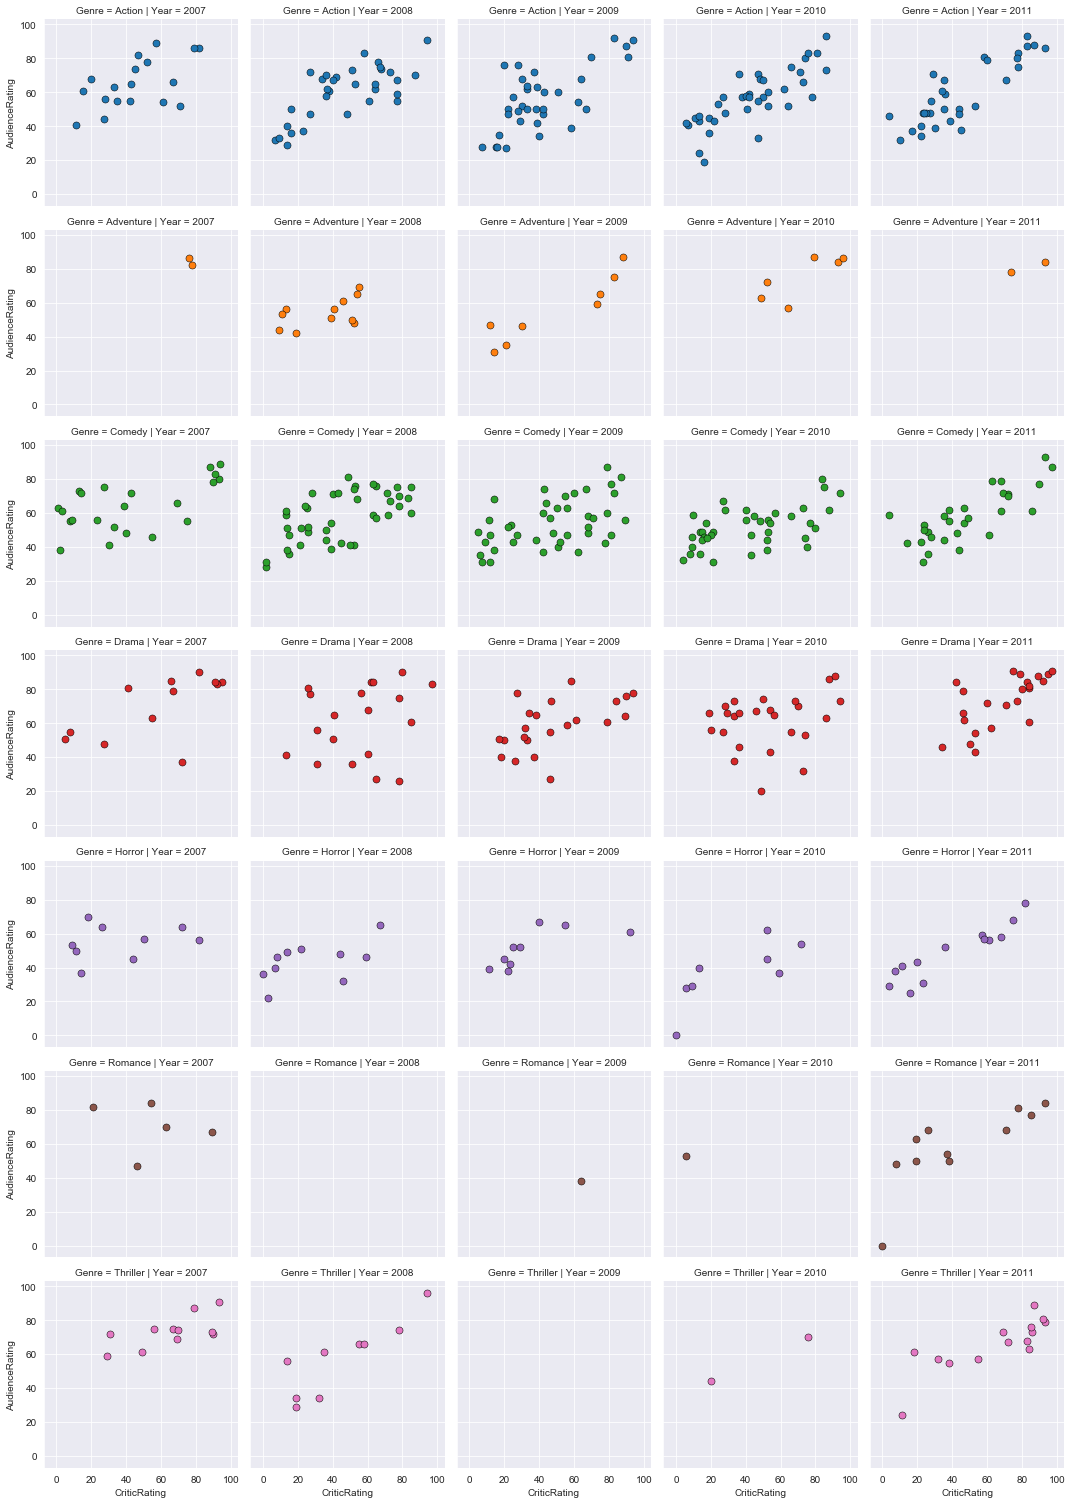

In [136]:
g = sns.FacetGrid(movies, row="Genre", col="Year", hue="Genre")
kws = dict(s = 50, linewidth=0.5, edgecolor='black')
g = g.map(plt.scatter,"CriticRating","AudienceRating", **kws)

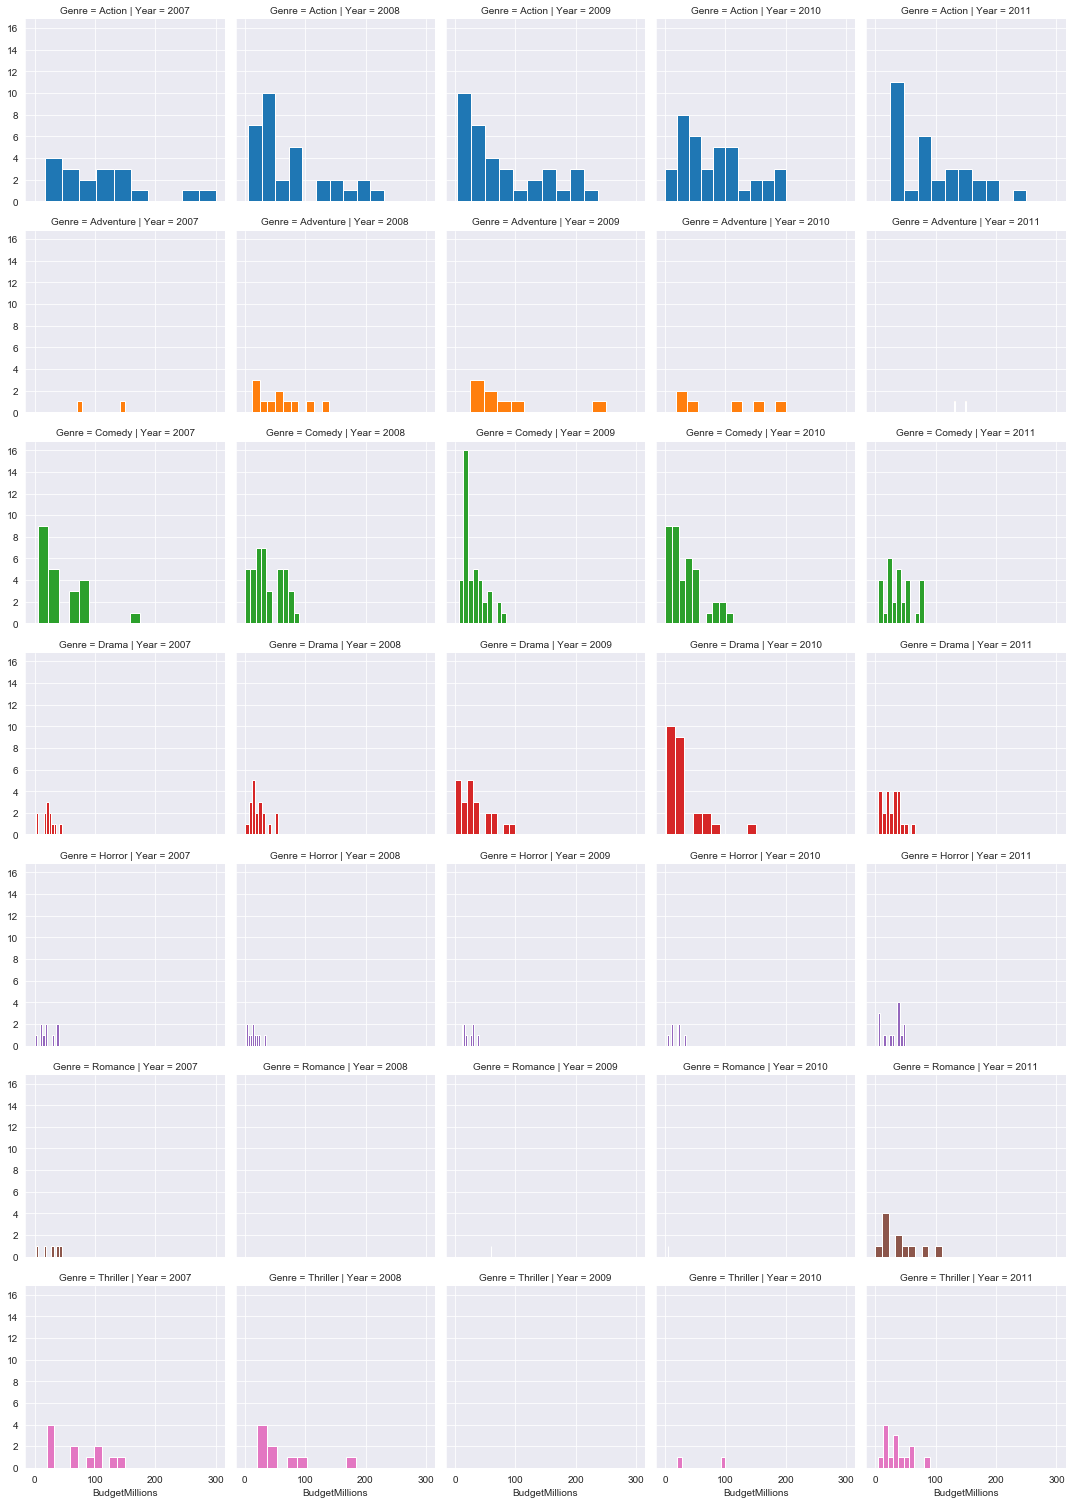

In [132]:
g = sns.FacetGrid(movies, row="Genre", col="Year", hue="Genre")
g = g.map(plt.hist,"BudgetMillions")

In [134]:
#Coordinates and Diagonials

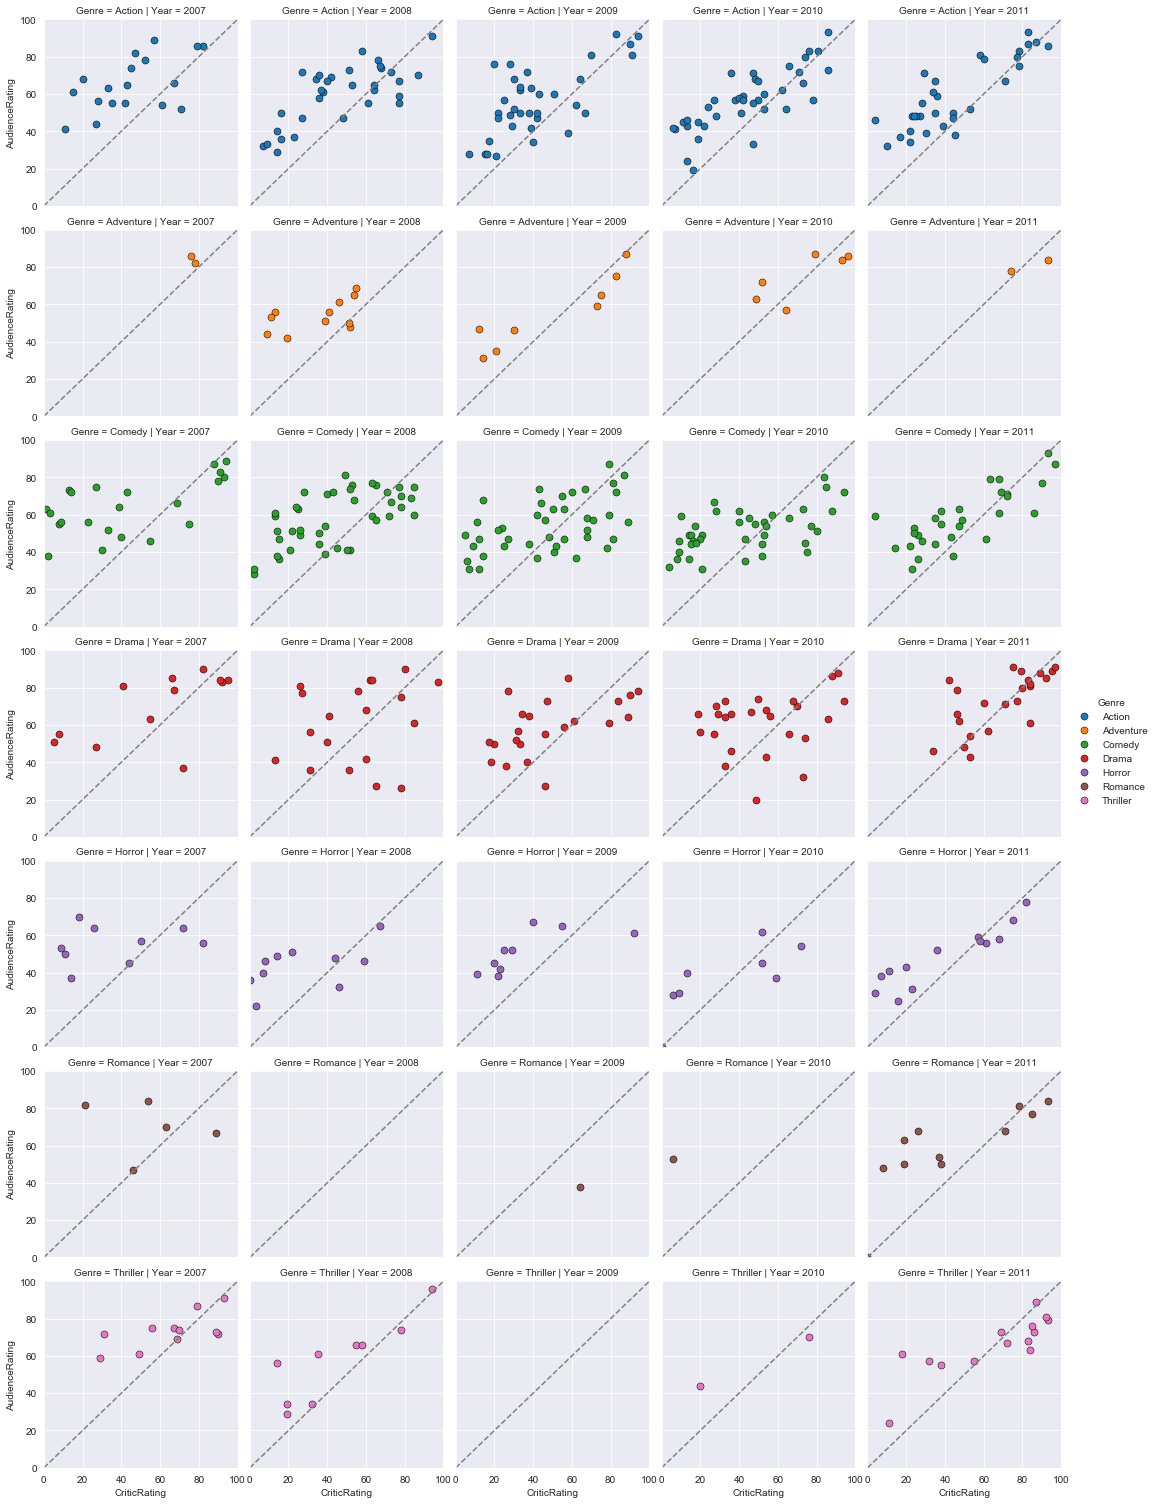

In [142]:
g = sns.FacetGrid(movies, row="Genre", col="Year", hue="Genre")
kws = dict(s = 50, linewidth=0.5, edgecolor='black')
g = g.map(plt.scatter,"CriticRating","AudienceRating", **kws)
g.set(xlim=(0,100), ylim=(0,100))
for ax in g.axes.flat:
    ax.plot((0,100), (0,100), c='gray',ls="--")
g.add_legend()

In [143]:
#Building Dashboards

[(-20, 160)]

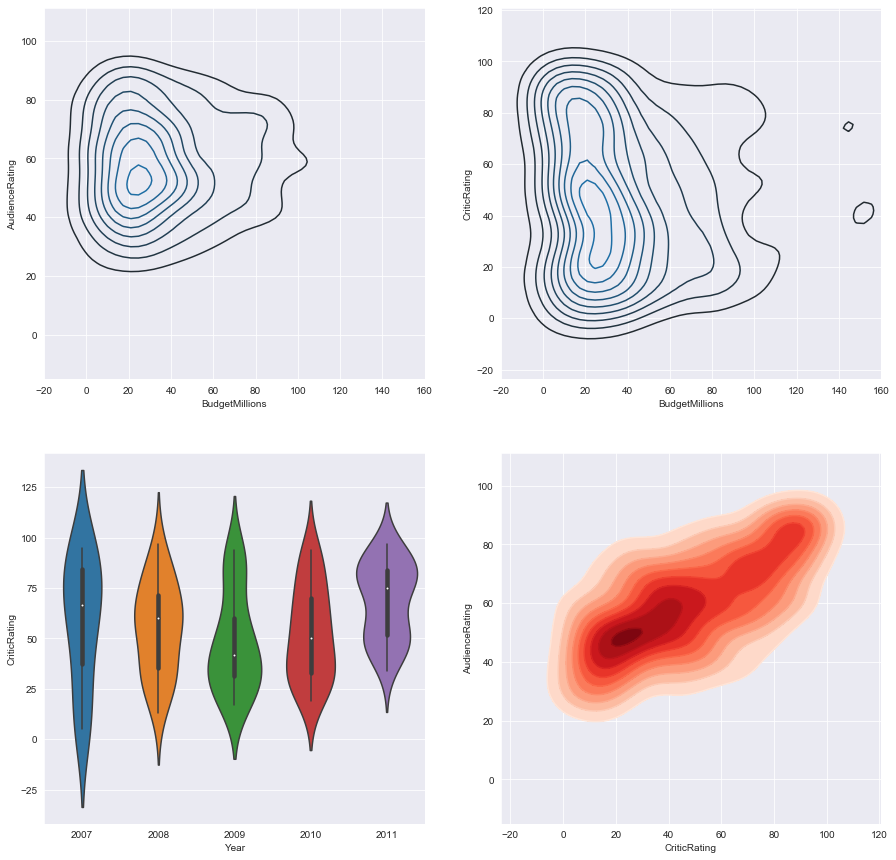

In [156]:
sns.set_style("darkgrid")
f , axis = plt.subplots(2, 2, figsize=(15,15))
k1 = sns.kdeplot(movies.BudgetMillions, movies.AudienceRating, ax=axis[0,0])
k2 = sns.kdeplot(movies.BudgetMillions, movies.CriticRating, ax=axis[0,1])
z = sns.violinplot(data=movies[movies.Genre=="Drama"],x="Year",y="CriticRating", ax=axis[1,0])
k3 = sns.kdeplot(movies.CriticRating, movies.AudienceRating, shade = True, shade_lowest=False, cmap="Reds",ax=axis[1,1])
k4 = sns.kdeplot(movies.CriticRating, movies.AudienceRating, cmap="Reds",ax=axis[1,1])
#axis[1,1].hist(movies.CriticRating, bins=15)
k1.set(xlim=(-20,160))
k2.set(xlim=(-20,160))

In [158]:
#Styling

[(-20, 160)]

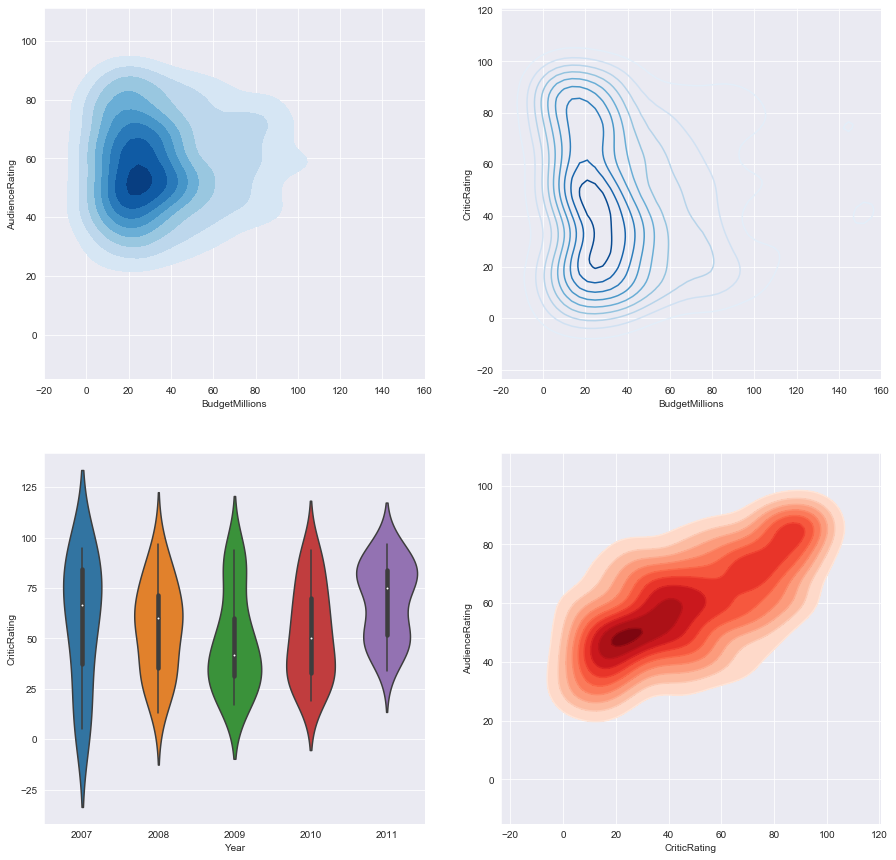

In [162]:
sns.set_style("darkgrid")
f , axis = plt.subplots(2, 2, figsize=(15,15))

#Plot 0.0
k1 = sns.kdeplot(movies.BudgetMillions, movies.AudienceRating, shade = True, shade_lowest=False, cmap="Blues",ax=axis[0,0])

#Plot 0.1
k2 = sns.kdeplot(movies.BudgetMillions, movies.CriticRating, cmap="Blues",ax=axis[0,1])

#Plot 1.0
z = sns.violinplot(data=movies[movies.Genre=="Drama"],x="Year",y="CriticRating", ax=axis[1,0])

#Plot 1.1
k3 = sns.kdeplot(movies.CriticRating, movies.AudienceRating, shade = True, shade_lowest=False, cmap="Reds",ax=axis[1,1])
k4 = sns.kdeplot(movies.CriticRating, movies.AudienceRating, cmap="Reds",ax=axis[1,1])

#axis[1,1].hist(movies.CriticRating, bins=15)
k1.set(xlim=(-20,160))
k2.set(xlim=(-20,160))